In [117]:
import sys
import numpy as np
import time
import matplotlib.pyplot as plt
import random
sys.path.append("C:/Users/spaceoptics/Desktop/Delay Line Code")  # PATH to hardware_ops.py

In [118]:
from hardware_ops import HardwareOps

In [119]:
config_filename =  r'C:\Users\spaceoptics\Desktop\Delay Line Code\hardware_config.json' #use this if you ned to store serial port numbers
ops = HardwareOps(config_filename)#initialized inside the __init__ functions

## Piezo Jacobian

### Initialize

In [120]:
# Initialize Piezos & Separate into X and Y
piezo_list = np.array(ops.piezo_serials_list)

mirror_1, mirror_2, mirror_3 = (
    piezo_list[0:2],
    piezo_list[2:4],
    piezo_list[4:6],
)

M1x = mirror_1[1]
M1y = mirror_1[0]
M2x = mirror_2[1]
M2y = mirror_2[0]
M3x = mirror_3[1]
M3y = mirror_3[0]

for sn in piezo_list:
    ops.piezos.set_voltage(sn, 0)

29253216 set to 0.0228888821069979
29253216 set to 0.0
29253237 set to 0.0137333292641987
29253237 set to 0.0
113250536 set to 0.00228888821069979
113250536 set to 0.0
113250437 set to 0.0
29253246 set to 0.0137333292641987
29253246 set to 0.0
113250516 set to 0.00228888821069979
113250516 set to 0.0


### Function Bank

In [121]:
def piezo_record(mirror, axes, target, step_size, verbose=True, settle_time=0.5, round_digits=3):
    """
    Move a piezo axis incrementally from a specified start to a target voltage.

    mirror: list to append movement data
    axes: list with a single axis to move
    start: starting voltage (can be non-zero)
    target: final voltage to reach
    step_size: maximum incremental step
    round_digits: number of decimals to round voltages for clean logging
    """

    ax = axes[0]
    idx = np.where(piezo_list == ax)[0][0] - 1

    # Read current voltage from hardware and override with start
    # v_current = ops.piezos.get_all_voltages()
    # v_current[idx] = start
    if mirror:  # continuation run
        v_current = np.array(mirror[-1]["v1"], dtype=float)
        start = v_current[idx]
    else:       # first run
        v_current = ops.piezos.get_all_voltages()
        v_current[idx] = 0.0
        start = 0.0

    # Compute direction and total jump
    direction = np.sign(target - start)
    jump = abs(target - start)

    # Determine full steps and last partial step
    n_full_steps = int(jump // step_size)
    last_step = jump - n_full_steps * step_size

    if verbose:
        print(f"Start: {start}, target: {target}, "
              f"{n_full_steps} full steps + last step {last_step:.4f}")

    # Helper to perform a single step
    def step(delta):
        nonlocal v_current
        v0 = v_current.copy()
        before = np.array(ops.quads.get_xy_position(sig_strength=0.02), dtype=float)
        b_SUM = np.array(ops.quads.get_signal_strength(), dtype=float)

        # Increment voltage
        v_current[idx] += direction * delta

        # Optional rounding for clean logging / avoiding tiny drift
        if round_digits is not None:
            v_current[idx] = round(v_current[idx], round_digits)

        ops.piezos.set_voltage(ax, v_current[idx])
        time.sleep(settle_time)

        v1 = v_current.copy()
        after = np.array(ops.quads.get_xy_position(sig_strength=0.02), dtype=float)
        a_SUM = np.array(ops.quads.get_signal_strength(), dtype=float)

        mirror.append({
            "v0": np.array(v0, dtype=float),
            "v1": np.array(v1, dtype=float),
            "before": np.array(before, dtype=float),
            "after": np.array(after, dtype=float),
            "b_SUM": np.array(b_SUM, dtype=float),
            "a_SUM": np.array(a_SUM, dtype=float)
        })

    # Perform full steps
    for _ in range(n_full_steps):
        step(step_size)

    # Perform last partial step if needed
    if last_step > 1e-9:
        step(last_step)

    if verbose:
        print(f"Final voltage: {v_current[idx]} (target was {target})")

    return mirror

def piezo_sweep(mirror, axes, targets, step_size, verbose=True, settle_time=0.5, round_digits=3): 
    """ Run piezo_record sequentially over a list/array of targets. """ 

    for i, target in enumerate(targets): 
        if verbose: print(f"\n--- Sweep {i}: moving to target {target} ---") 
        mirror = piezo_record( mirror=mirror, axes=axes, target=target, step_size=step_size, verbose=verbose, settle_time=settle_time, round_digits=round_digits ) 

    return mirror

def generate_sequence(length, min_val=0, max_val=50):
    """ Generats a list of voltages over which the Piezos will run."""

    sequence = [0]  # Start at 0
    
    for _ in range(length - 1):
        step = random.randint(1, 8)
        direction = random.choice([-1, 1])
        next_value = sequence[-1] + direction * step
        
        # Keep within bounds
        if next_value < min_val:
            next_value = sequence[-1] + step
        elif next_value > max_val:
            next_value = sequence[-1] - step
        
        sequence.append(next_value)
    
    return sequence

def plot_piezo(M):
    """ Plots the Piezo data, including Mirrors 1, 2, & 3 with step sizes on the dependant axis"""
    
    V_r = np.array([m["v1"] - m["v0"] for m in M])  # shape (n_steps, n_axes)
    Q_r = np.array([m["after"] - m["before"] for m in M])  # shape (n_steps, 4)
    Sum = np.array([m["b_SUM"] - m["a_SUM"] for m in M]) # shape(n_steps, 2)

    # Conversion Factor
    # Q_r[:, 2] *= 3.823806299791969
    # Q_r[:, 3] *= 3.823806299791969

    # V = np.vstack([V_1, V_2, V_3, V_r])  # shape: (n_steps_total, n_axes)
    # Q = np.vstack([Q_1, Q_2, Q_3, Q_r])  # shape: (n_steps_total, 4)

    Vx = np.array([v[v != 0][0] for v in V_r])  # shape: (n_steps,)
    # Labels for Q components
    q_labels = ["Q1x", "Q1y", "Q2x", "Q2y"]

    V_row = V_r[V_r != 0]
    V_vector = V_row.reshape(-1, 1)

    j = np.linalg.pinv(V_vector) @ Q_r
    print("Jacobian:", j)

    # plt.figure(figsize=(8,6))
    # for i in range(Q_r.shape[1]):  # loop over 4 quadrants
    #     plt.scatter(V_r[:, 3], Q_r[:, i], label=q_labels[i], alpha=0.5)  # assuming your piezo axis is at index 3

    # plt.xlabel("Voltage change (v1-v0) for piezo axis")
    # plt.ylabel("Quadrant movement")
    # plt.title("Individual Quadrant Responses")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    # Create 1x4 subplots
    fig, axs1 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    for i in range(4):
        axs1[i].scatter(Vx, Q_r[:, i], alpha=0.5)
        axs1[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axs1[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
        axs1[i].set_xlabel("Voltage step (V)")
        axs1[i].set_title(q_labels[i])

    axs1[0].set_ylabel("Quadrant response")

    plt.tight_layout()
    plt.show()

    fig, axs2 = plt.subplots(1, 2, figsize=(16,4), sharey=True)

    for i in range(2):
        axs2[i].plot(Sum[:, i], alpha=0.5)
        axs2[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
        axs2[i].set_xlabel("Instance")
        axs2[i].set_title(f"QuadCell {i+1} SUM")

    axs2[0].set_ylabel("Quadcell SUM Response")

    plt.tight_layout()
    plt.show()



In [ ]:
ops.quads.get_xy_position() # after 2mm linear movement of M2

[0.0772118289742729, -0.005188146610919523, 0.453, -0.02075258644367809]

### Experiments

In [126]:
# This initializes mirror lists and the targets for the mirrors
step_size = 10

targets = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,19,18,17,16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0,2,4,6,8,10,12,14,16,18,20,18,16,14,12,10,8,6,4,20,3,6,9,12,15,18,20,17,14,11,8,5,2,0,4,8,12,16,20,16,12,8,4,0,5,10,15,20,15,10,5,0]
#                                                            #20                                                                        #50                      #59               #66                          #78                     #87   

m1 = []
m2 = []
m3 = []

In [127]:
# This takes the measurements
# Before changing the variable name, remember to change it in both _ = piezo_sweep(_, ...)
m1 = piezo_sweep(m1, [M1x], targets, step_size, False)
m2 = piezo_sweep(m2, [M2x], targets, step_size, False)
m3 = piezo_sweep(m3, [M3x], targets, step_size, False)

29253237 set to 0.0411999877925962
29253237 set to 1.0
29253237 set to 1.00711081270791
29253237 set to 2.0
29253237 set to 2.00506607257302
29253237 set to 3.0
29253237 set to 3.00759910885952
29253237 set to 4.0
29253237 set to 4.01013214514603
29253237 set to 5.0
29253237 set to 5.00808740501114
29253237 set to 6.0
29253237 set to 6.01519821771905
29253237 set to 7.0
29253237 set to 7.01773125400556
29253237 set to 8.0
29253237 set to 8.01568651387066
29253237 set to 9.0
29253237 set to 9.01364177373577
29253237 set to 10.0
29253237 set to 10.0115970336009
29253237 set to 11.0
29253237 set to 11.0141300698874
29253237 set to 12.0
29253237 set to 12.0166631061739
29253237 set to 13.0
29253237 set to 13.014618366039
29253237 set to 14.0
29253237 set to 14.0217291787469
29253237 set to 15.0
29253237 set to 15.0242622150334
29253237 set to 16.0
29253237 set to 16.0176396984771
29253237 set to 17.0
29253237 set to 17.024750511185
29253237 set to 18.0
29253237 set to 18.0227057710501
2925

In [124]:
# Initial Mirror Setup
np.savez("output1_4_28_Jac1.npz", m1=m1)
np.savez("output1_4_28_Jac2.npz", m2=m2)
np.savez("output1_4_28_Jac3.npz", m3=m3)


# Move stages, use ODL, Then Align

# Linear Stage Movement Setup
# np.savez("output2_4_28_Jac1.npz", m1=m1)
# np.savez("output2_4_28_Jac2.npz", m2=m2)
# np.savez("output2_4_28_Jac3.npz", m3=m3)


# Jump reflections, Compare ODL

# # Reflection Jump Setup
# np.savez("output3_4_28_Jac1.npz", m1=m1)
# np.savez("output3_4_28_Jac2.npz", m2=m2)
# np.savez("output3_4_28_Jac3.npz", m3=m3)


# Load Later
# data = np.load("_.npz")
# b = data["b"]

In [ ]:
# PS: Plots will show SUM, aka the difference between the SUM values before and after each Movement.
# Future use: b(efore)_SUM and a(fter)_SUM are expected to be near identical, but b_SUM will have a value before movement & a_SUM will have a value after movement.
# Note: It might be useful to preemptively link v1 & b_SUM, and v2 & a_SUM to account for QuadCell scaling in X & Y.

print("Mirror 1x")
plot_piezo(m1)

print("Mirror 2x")
plot_piezo(m2)

print("Mirror 3x")
plot_piezo(m3)

### QuadCell Diff

- X_diff = v1 + v2 - (v3 + v4)
- Y_diff = v4 + v1 - (v2 + v3) 
- ^^ Dont know what the v's stand for
- X_out = X_diff/SUM
- Y_out = Y_diff/SUM
- 4 inputs & 3 outputs, therefore unsolveable. Contact Paige for solutions?

## Analysis Attempts

In [ ]:
V_r1 = np.array([m["v1"] - m["v0"] for m in m1])  # shape (n_steps, n_axes)
Q_r1 = np.array([m["after"] - m["before"] for m in m1])  # shape (n_steps, 4)
Sum1 = np.array([m["b_SUM"] - m["a_SUM"] for m in m1]) # shape(n_steps, 2)

q_labels = ["Q1x", "Q1y", "Q2x", "Q2y"]

fig, axs1 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for i in range(4):
    axs1[i].scatter(Q_r1[:, i], Sum1[:, 0], alpha=0.5)
    axs1[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs1[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axs1[i].set_xlabel("Quadcell 1 Response")
    axs1[i].set_title(q_labels[i])
    
axs1[0].set_ylabel(f"Quadcell 1 Sum")
plt.tight_layout()
plt.show()

fig, axs2 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for j in range(4):
    axs2[j].scatter(Q_r1[:, j], Sum1[:, 1], alpha=0.5)
    axs2[j].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs2[j].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axs2[j].set_xlabel("Quadcell 2 Response")
    axs2[j].set_title(q_labels[j])
    
axs2[0].set_ylabel(f"Quadcell 2 Sum")
plt.tight_layout()
plt.show()


In [ ]:
b = np.array([m["b_SUM"] for m in m1])
plt.plot(b[:, 0], label="Quadcell 1")
plt.xlabel("Iteration")
plt.ylabel("Quadcell 1 SUM Response Before Movement")
plt.show()
plt.plot(b[:, 1], label="Quadcell 2")
plt.xlabel("Iteration")
plt.ylabel("Quadcell 1 SUM Response After Movement")
plt.show()


a = np.array([m["a_SUM"] for m in m1])
plt.plot(a[:, 0], label="Quadcell 1")
plt.xlabel("Iteration")
plt.ylabel("Quadcell 2 SUM Response Before Movement")
plt.show()
plt.plot(a[:, 1], label="Quadcell 2")
plt.xlabel("Iteration")
plt.ylabel("Quadcell 2 SUM Response After Movement")
plt.show()


In [ ]:
V_r2 = np.array([m["v1"] - m["v0"] for m in m2])  # shape (n_steps, n_axes)
Q_r2 = np.array([m["after"] - m["before"] for m in m2])  # shape (n_steps, 4)
Sum2 = np.array([m["b_SUM"] - m["a_SUM"] for m in m2]) # shape(n_steps, 2)

q_labels = ["Q1x", "Q1y", "Q2x", "Q2y"]

fig, axs1 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for i in range(4):
    axs1[i].scatter(Q_r2[:, i], Sum2[:, 0], alpha=0.5)
    axs1[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs1[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axs1[i].set_xlabel("Quadcell 1 Response")
    axs1[i].set_title(q_labels[i])
    
axs1[0].set_ylabel(f"Quadcell 1 Sum")
plt.tight_layout()
plt.show()

fig, axs2 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for j in range(4):
    axs2[j].scatter(Q_r2[:, j], Sum2[:, 1], alpha=0.5)
    axs2[j].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs2[j].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axs2[j].set_xlabel("Quadcell 2 Response")
    axs2[j].set_title(q_labels[j])
    
axs2[0].set_ylabel(f"Quadcell 2 Sum")
plt.tight_layout()
plt.show()

In [ ]:
V_r3 = np.array([m["v1"] - m["v0"] for m in m3])  # shape (n_steps, n_axes)
Q_r3 = np.array([m["after"] - m["before"] for m in m3])  # shape (n_steps, 4)
Sum3 = np.array([m["b_SUM"] - m["a_SUM"] for m in m3]) # shape(n_steps, 2)

q_labels = ["Q1x", "Q1y", "Q2x", "Q2y"]

fig, axs1 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for i in range(4):
    axs1[i].scatter(Q_r3[:, i], Sum3[:, 0], alpha=0.5)
    axs1[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs1[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axs1[i].set_xlabel("Quadcell 1 Response")
    axs1[i].set_title(q_labels[i])
    
axs1[0].set_ylabel(f"Quadcell 1 Sum")
plt.tight_layout()
plt.show()

fig, axs2 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for j in range(4):
    axs2[j].scatter(Q_r3[:, j], Sum3[:, 1], alpha=0.5)
    axs2[j].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs2[j].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axs2[j].set_xlabel("Quacdell 2 Response")
    axs2[j].set_title(q_labels[j])
    
axs2[0].set_ylabel(f"Quadcell 2 Sum")
plt.tight_layout()
plt.show()

## Notes: 

Plotting Sum vs X & Y Responses:
- Mirrors 2 & 3 display peculiar linear, sectioned plots for QC 1. This is not observed in QC 2.
- Mirror 1 Ranges: X=(0.02, 0.001, 0.1, 0.015) & Y=(0.0008, 0.006)
- Mirror 2 Ranges: X=(0.01, 0.002, 0.1, 0.02) & Y=(0.0003, 0.002)
- Mirror 3 Ranges: X=(0.01, 0.0015, 0.1, 0.015) & Y=(0.0003, 0.002)
- Observations: Y's are 2x smaller for 2 & 3. X is smaller for 1x, bigger for 1y, the same for 2x and 2y.


Mirror 1x
Jacobian: [[-2.36913010e-03 -6.94610459e-06 -1.49079514e-02 -1.33660793e-04]]


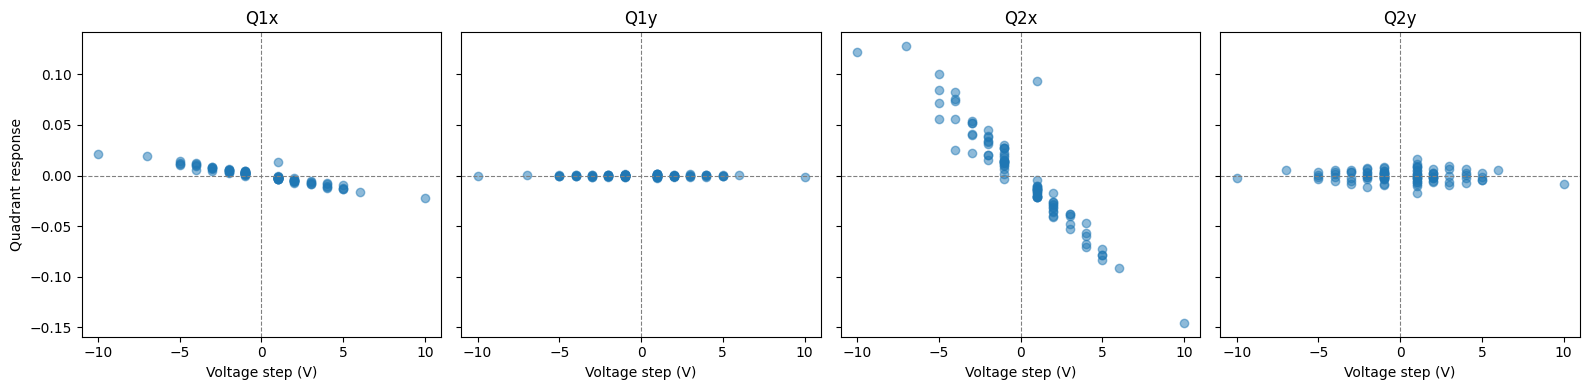

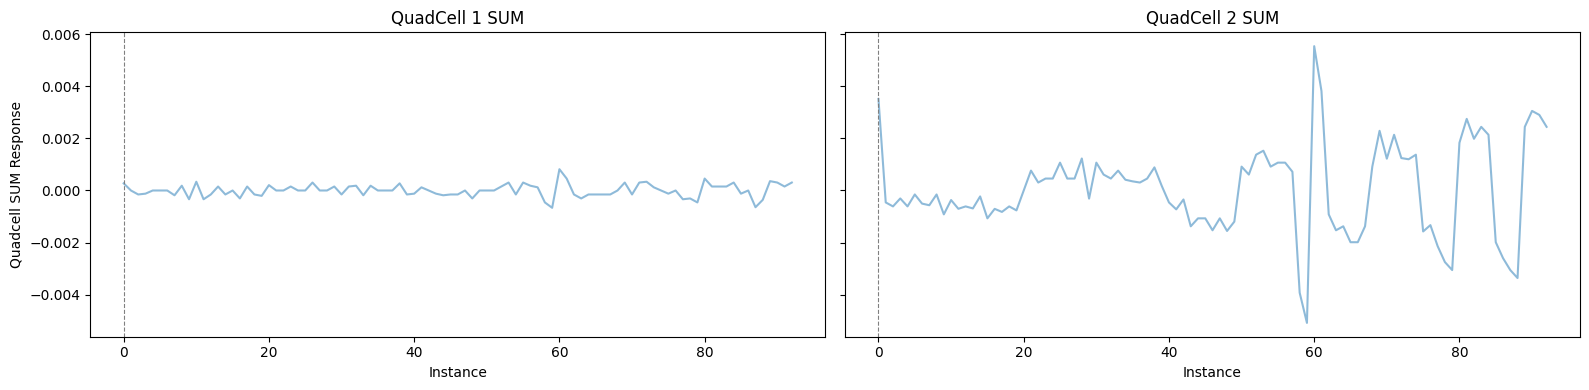

Mirror 2x
Jacobian: [[ 1.41680199e-03 -2.17009915e-05  1.15464752e-02 -1.42794905e-04]]


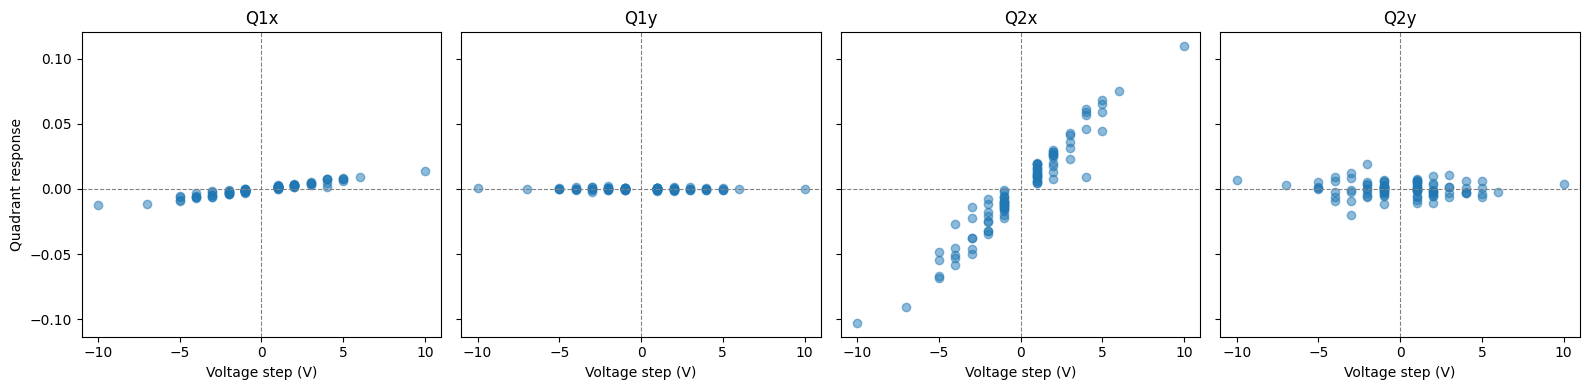

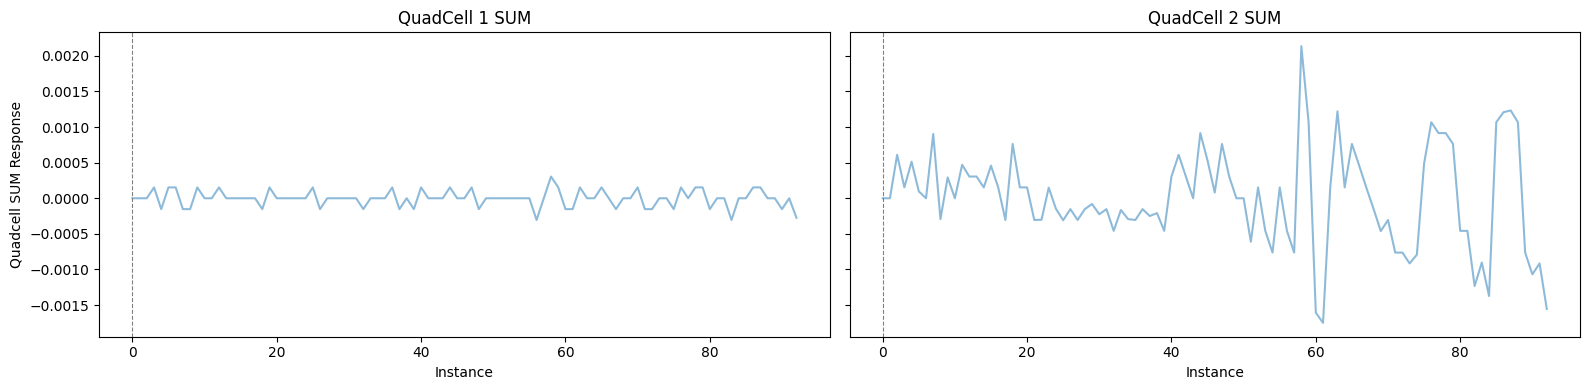

Mirror 3x
Jacobian: [[ 1.30495833e-03 -2.80110466e-05  1.12556759e-02 -9.03669314e-05]]


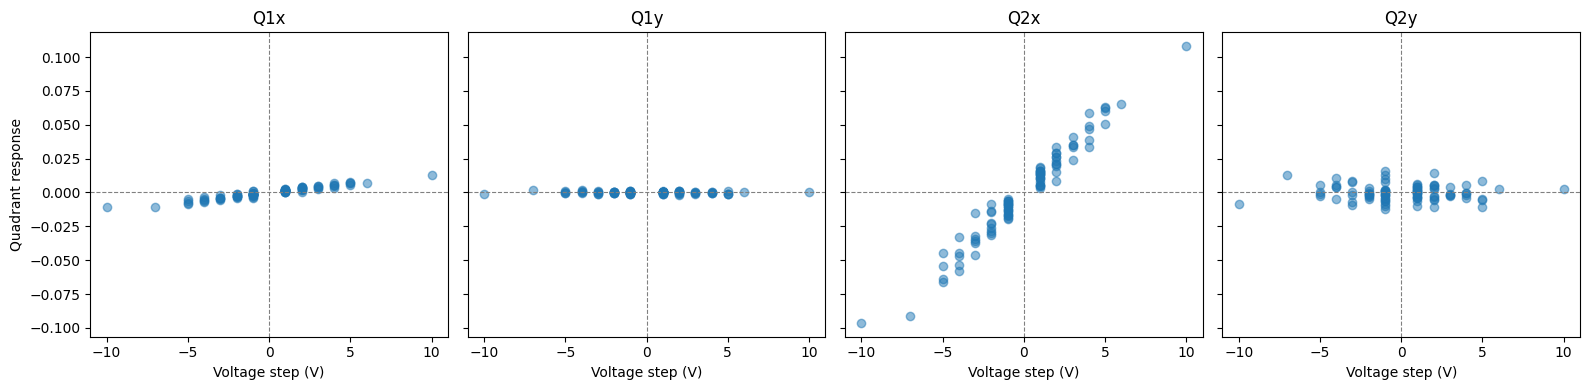

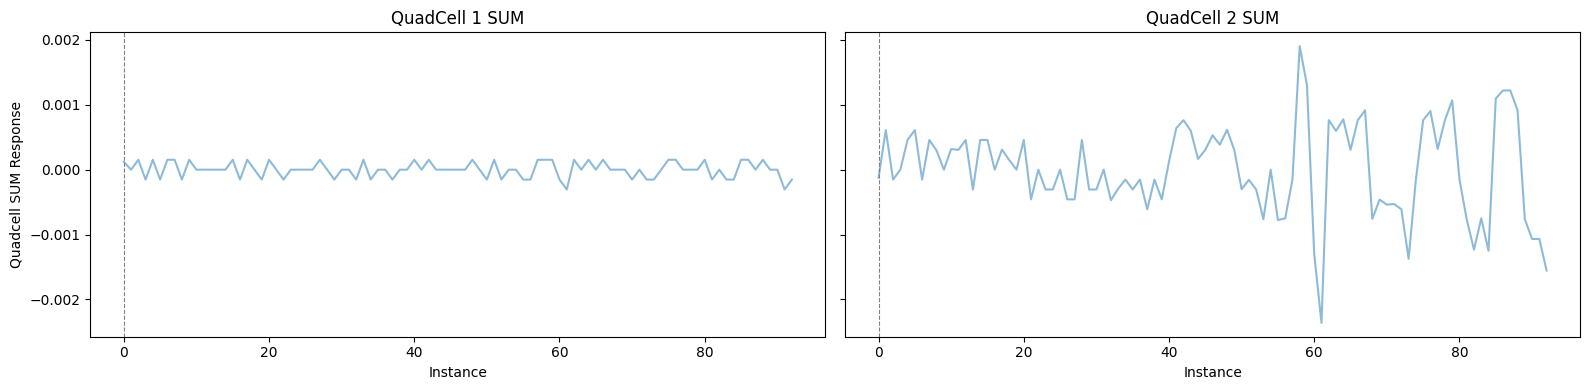

In [85]:
print("Mirror 1x")
plot_piezo(m1)

print("Mirror 2x")
plot_piezo(m2)

print("Mirror 3x")
plot_piezo(m3)

In [ ]:
# # With Signal Strength scaled for Quadcell 2


# def piezo_strength(mirror, axes, target, step_size, verbose=True, settle_time=0.5, round_digits=3):
#     """
#     Move a piezo axis incrementally from a specified start to a target voltage.
#     """

#     ax = axes[0]
#     idx = np.where(piezo_list == ax)[0][0] - 1

#     if mirror:  # continuation run
#         v_current = np.array(mirror[-1]["v1"], dtype=float)
#         start = v_current[idx]
#     else:       # first run
#         v_current = ops.piezos.get_all_voltages()
#         v_current[idx] = 0.0
#         start = 0.0

#     direction = np.sign(target - start)
#     jump = abs(target - start)

#     n_full_steps = int(jump // step_size)
#     last_step = jump - n_full_steps * step_size

#     if verbose:
#         print(f"Start: {start}, target: {target}, "
#               f"{n_full_steps} full steps + last step {last_step:.4f}")

#     def step(delta):
#         nonlocal v_current

#         v0 = v_current.copy()
#         before = np.array(ops.quads.get_xy_position(sig_strength=0.02), dtype=float)
#         b_SUM = np.array(ops.quads.get_sig_strength(), dtype=float)

#         # Increment voltage
#         v_current[idx] += direction * delta

#         if round_digits is not None:
#             v_current[idx] = round(v_current[idx], round_digits)

#         ops.piezos.set_voltage(ax, v_current[idx])
#         time.sleep(settle_time)

#         v1 = v_current.copy()
#         after = np.array(ops.quads.get_xy_position(sig_strength=0.02), dtype=float)
#         a_SUM = np.array(ops.quads.get_sig_strength(), dtype=float)

#         # ✅ NEW: measure signal strength every step
#         strength = ops.quads.get_signal_strength()

#         mirror.append({
#             "v0": np.array(v0, dtype=float),
#             "v1": np.array(v1, dtype=float),
#             "before": np.array(before, dtype=float),
#             "after": np.array(after, dtype=float),
#             "strength": np.array(strength, dtype=float),
#             "b_SUM": np.array(b_SUM, dtype=float),
#             "a_SUM": np.array(a_SUM, dtype=float)
#         })

#     for _ in range(n_full_steps):
#         step(step_size)

#     if last_step > 1e-9:
#         step(last_step)

#     if verbose:
#         print(f"Final voltage: {v_current[idx]} (target was {target})")

#     return mirror

# def piezo_check(mirror, axes, targets, step_size, verbose=True, settle_time=0.5, round_digits=3): 
#     """ Run piezo_record sequentially over a list/array of targets. """ 
#     for i, target in enumerate(targets): 
#         if verbose: print(f"\n--- Sweep {i}: moving to target {target} ---") 
#         mirror = piezo_strength( mirror=mirror, axes=axes, target=target, step_size=step_size, verbose=verbose, settle_time=settle_time, round_digits=round_digits ) 
#     return mirror

# def plot_converted_piezo(M):
#     V_r = np.array([m["v1"] - m["v0"] for m in M])  # shape (n_steps, n_axes)
#     Q_r = np.array([m["after"] - m["before"] for m in M])  # shape (n_steps, 4)

#     strengths1 = np.array([entry["strength"] for entry in M])

#     mean_q1 = np.mean(strengths1[:, 0])
#     mean_q2 = np.mean(strengths1[:, 1])

#     Sig_strength_conv = mean_q1/mean_q2  
    
#     print("Signal Strength Conversion(Q1/Q2 for Mirror 1): ", Sig_strength_conv)

#     Vx = np.array([v[v != 0][0] for v in V_r])  # shape: (n_steps,)

#     # Labels for Q components
#     q_labels = ["Q1x", "Q1y", "Q2x", "Q2y"]

#     V_row = V_r[V_r != 0]
#     V_vector = V_row.reshape(-1, 1)

#     Q_r[:, 2] *= Sig_strength_conv
#     Q_r[:, 3] *= Sig_strength_conv

#     j = np.linalg.pinv(V_vector) @ Q_r
#     print("Jacobian:", j)

#     # plt.figure(figsize=(8,6))
#     # for i in range(Q_r.shape[1]):  # loop over 4 quadrants
#     #     plt.scatter(V_r[:, 3], Q_r[:, i], label=q_labels[i], alpha=0.5)  # assuming your piezo axis is at index 3

#     # plt.xlabel("Voltage change (v1-v0) for piezo axis")
#     # plt.ylabel("Quadrant movement")
#     # plt.title("Individual Quadrant Responses")
#     # plt.legend()
#     # plt.grid(True)
#     # plt.show()

#     # Create 1x4 subplots
#     fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

#     for i in range(4):
#         axs[i].scatter(Vx, Q_r[:, i], alpha=0.5)
#         axs[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
#         axs[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
#         axs[i].set_xlabel("Voltage step (V)")
#         axs[i].set_title(q_labels[i])

#     axs[0].set_ylabel("Quadrant response")

#     plt.tight_layout()
#     plt.show()

#     fig, axs2 = plt.subplots(1, 2, figsize=(16,4), sharey=True)

#     for i in range(2):
#         axs2[i].scatter(Q_r, strengths1[:, i], alpha=0.5)
#         axs2[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
#         axs2[i].set_xlabel("Instance")
#         axs2[i].set_title("QuadCell", i, "SUM")

#     axs2[0].set_ylabel("Quadcell SUM Response")

#     plt.tight_layout()
#     plt.show()


Mirror 1x
Signal Strength Conversion(Q1/Q2 for Mirror 1):  0.1611718520910286
Jacobian: [[-2.40513516e-03  3.12380257e-05 -2.41582839e-03  3.73717757e-06]]


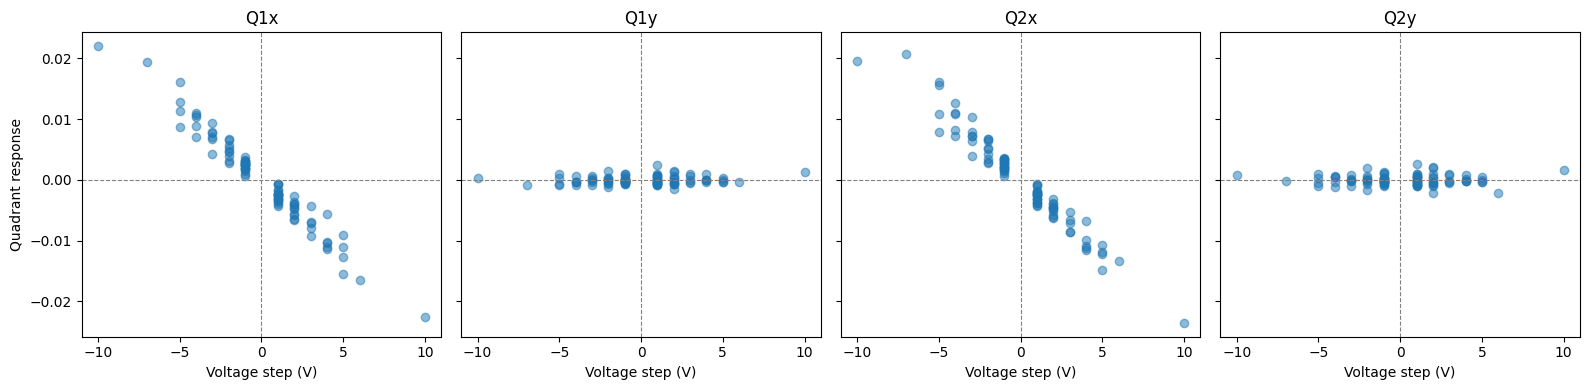

ValueError: x and y must be the same size

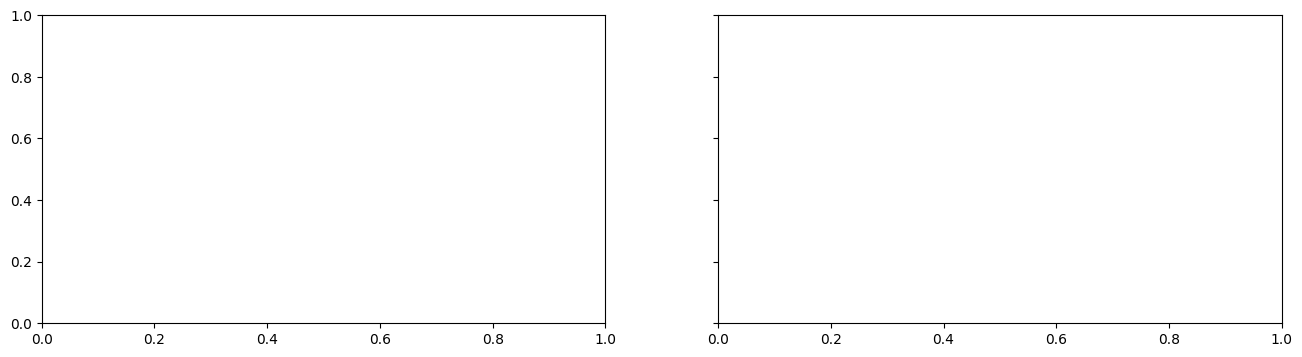

In [ ]:
print("Mirror 1x")
plot_converted_piezo(m1)

print("Mirror 2x")
plot_converted_piezo(m2)

print("Mirror 3x")
plot_converted_piezo(m3)

### Plotting through Time: Combined Q1x, Q1y, Q2x & Q2y w/ Conversion Factors

3.4086678097850935


<Figure size 640x480 with 0 Axes>

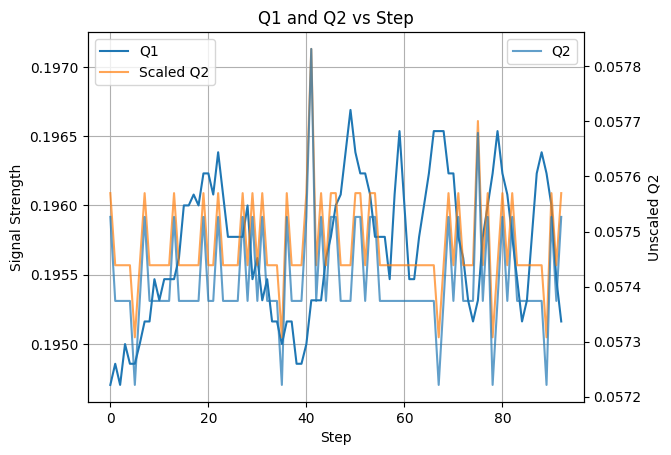

3.3899198506959527


<Figure size 640x480 with 0 Axes>

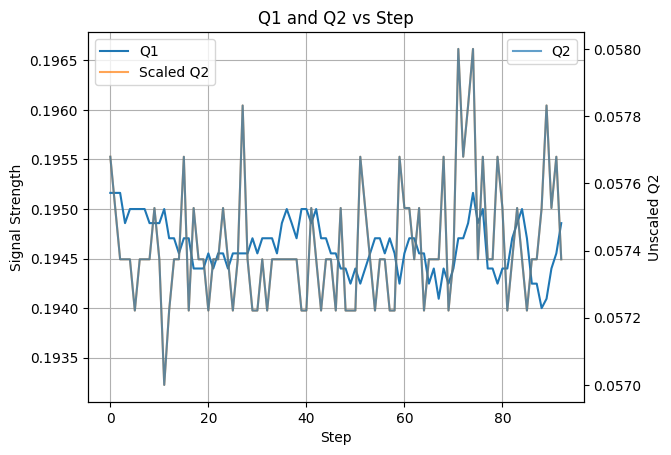

3.3808241256911837


<Figure size 640x480 with 0 Axes>

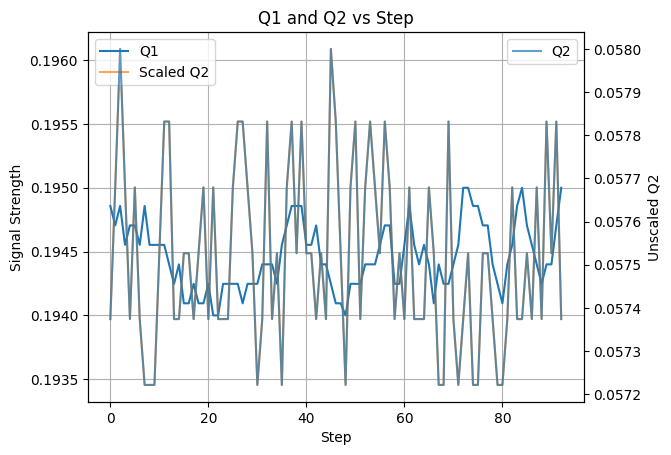

In [47]:
import numpy as np
import matplotlib.pyplot as plt

strengths1 = np.array([entry["strength"] for entry in m_1])
strengths2 = np.array([entry["strength"] for entry in m_2])
strengths3 = np.array([entry["strength"] for entry in m_3])

q11 = strengths1[:, 0]
q21 = strengths1[:, 1]
q12 = strengths2[:, 0]
q22 = strengths2[:, 1]
q13 = strengths3[:, 0]
q23 = strengths3[:, 1]

mean_q11 = np.mean(strengths1[:, 0])
mean_q21 = np.mean(strengths1[:, 1])
mean_q12 = np.mean(strengths2[:, 0])
mean_q22 = np.mean(strengths2[:, 1])
mean_q13 = np.mean(strengths3[:, 0])
mean_q23 = np.mean(strengths3[:, 1])

conv1 = mean_q11/mean_q21
conv2 = mean_q12/mean_q22
conv3 = mean_q13/mean_q23

print(conv1)
plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(q11, label="Q1")
ax1.plot(q21*conv1, label="Scaled Q2", alpha=0.7)
ax2.plot(q21, label="Q2", alpha=0.7)
ax1.set_xlabel("Step")
ax1.set_ylabel("Signal Strength")
ax2.set_ylabel("Unscaled Q2")
plt.title("Q1 and Q2 vs Step")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True)
plt.show()

print(conv2)
plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(q12, label="Q1")
ax1.plot(q22*conv2, label="Scaled Q2", alpha=0.7)
ax2.plot(q22, label="Q2", alpha=0.7)
ax1.set_xlabel("Step")
ax1.set_ylabel("Signal Strength")
ax2.set_ylabel("Unscaled Q2")
plt.title("Q1 and Q2 vs Step")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True)
plt.show()

print(conv3)
plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(q13, label="Q1")
ax1.plot(q23*conv3, label="Scaled Q2", alpha=0.7)
ax2.plot(q23, label="Q2", alpha=0.7)
ax1.set_xlabel("Step")
ax1.set_ylabel("Signal Strength")
ax2.set_ylabel("Unscaled Q2")
plt.title("Q1 and Q2 vs Step")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True)
plt.show()

C:\Users\spaceoptics\AppData\Local\Temp\ipykernel_11704\3181409456.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

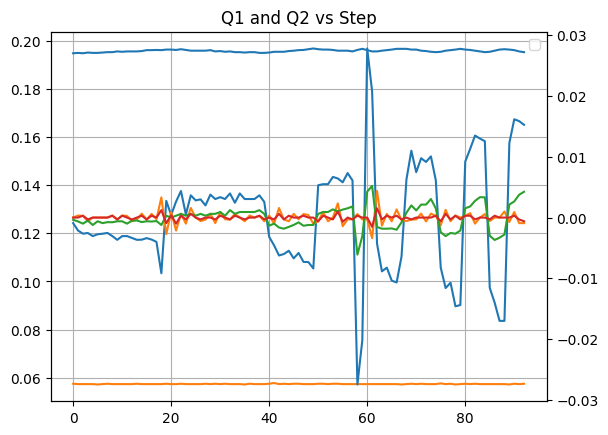

C:\Users\spaceoptics\AppData\Local\Temp\ipykernel_11704\3181409456.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

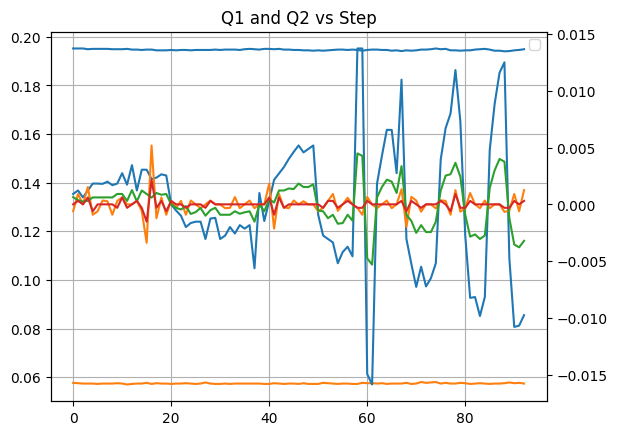

C:\Users\spaceoptics\AppData\Local\Temp\ipykernel_11704\3181409456.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

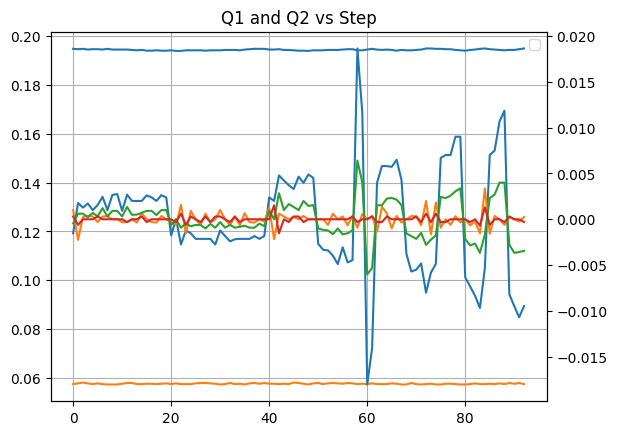

In [41]:
import numpy as np
import matplotlib.pyplot as plt

strengths1 = np.array([entry["strength"] for entry in m_1])
strengths2 = np.array([entry["strength"] for entry in m_2])
strengths3 = np.array([entry["strength"] for entry in m_3])

movement10 = np.array([entry["before"] for entry in m_1])
movement11 = np.array([entry["after"] for entry in m_1])
movement20 = np.array([entry["before"] for entry in m_2])
movement21 = np.array([entry["after"] for entry in m_2])
movement30 = np.array([entry["before"] for entry in m_3])
movement31 = np.array([entry["after"] for entry in m_3])

movement1 = movement11 - movement10
movement2 = movement21 - movement20
movement3 = movement31 - movement30

q11 = strengths1[:, 0]
q21 = strengths1[:, 1]
q12 = strengths2[:, 0]
q22 = strengths2[:, 1]
q13 = strengths3[:, 0]
q23 = strengths3[:, 1]

plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(q11, label="Q1")
ax1.plot(q21, label="Q2")
ax2.plot(movement1)
# ax1.set_xlabel("Step")
# ax1.set_ylabel("Signal Strength")
# ax2.set_ylabel("Movement Size")
plt.title("Q1 and Q2 vs Step")
plt.legend()
ax1.grid(True)
plt.show()

plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(q12, label="Q1")
ax1.plot(q22, label="Q2")
ax2.plot(movement2)
# ax1.set_xlabel("Step")
# ax1.set_ylabel("Signal Strength")
# ax2.set_ylabel("Movement Size")
plt.title("Q1 and Q2 vs Step")
plt.legend()
ax1.grid(True)
plt.show()

plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(q13, label="Q1")
ax1.plot(q23, label="Q2")
ax2.plot(movement3)
# ax1.set_xlabel("Step")
# ax1.set_ylabel("Signal Strength")
# ax2.set_ylabel("Movement Size")
plt.title("Q1 and Q2 vs Step")
plt.legend()
ax1.grid(True)
plt.show()

### QuadCell Conversion Factor Calculation Bank

In [16]:
# From Readings made on Mar 10th

mean_q11 = np.mean(strengths1[:, 0])
mean_q21 = np.mean(strengths1[:, 1])
mean_q12 = np.mean(strengths2[:, 0])
mean_q22 = np.mean(strengths2[:, 1])
mean_q13 = np.mean(strengths3[:, 0])
mean_q23 = np.mean(strengths3[:, 1])

print("For Mirror 1")
print("Mean Q1:", mean_q11)
print("Mean Q2:", mean_q21)
print("For Mirror 2")
print("Mean Q1:", mean_q12)
print("Mean Q2:", mean_q22)
print("For Mirror 3")
print("Mean Q1:", mean_q13)
print("Mean Q2:", mean_q23)

Sig_strength_conv1 = mean_q11/mean_q21
Sig_strength_conv2 = mean_q12/mean_q22
Sig_strength_conv3 = mean_q13/mean_q23

print("Signal Strength Conversion(Q1/Q2 for Mirror 1): ", Sig_strength_conv1)
print("Signal Strength Conversion(Q1/Q2 for Mirror 2): ", Sig_strength_conv2)
print("Signal Strength Conversion(Q1/Q2 for Mirror 3): ", Sig_strength_conv3)

For Mirror 1
Mean Q1: 0.19463057825950342
Mean Q2: 0.05634856036050671
For Mirror 2
Mean Q1: 0.19487303181177912
Mean Q2: 0.056292566313165995
For Mirror 3
Mean Q1: 0.19479538636089552
Mean Q2: 0.05637788557538408
Signal Strength Conversion(Q1/Q2 for Mirror 1):  3.4540470424496434
Signal Strength Conversion(Q1/Q2 for Mirror 2):  3.461789798810455
Signal Strength Conversion(Q1/Q2 for Mirror 3):  3.455173679765454


In [ ]:
# From Readings made on Feb 27th
mean_q11 = np.mean(strengths1[:, 0])
mean_q21 = np.mean(strengths1[:, 1])
mean_q12 = np.mean(strengths2[:, 0])
mean_q22 = np.mean(strengths2[:, 1])
mean_q13 = np.mean(strengths3[:, 0])
mean_q23 = np.mean(strengths3[:, 1])

print("For Mirror 1")
print("Mean Q1:", mean_q11)
print("Mean Q2:", mean_q21)
print("For Mirror 2")
print("Mean Q1:", mean_q12)
print("Mean Q2:", mean_q22)
print("For Mirror 3")
print("Mean Q1:", mean_q13)
print("Mean Q2:", mean_q23)

Sig_strength_conv1 = mean_q11/mean_q21
Sig_strength_conv2 = mean_q12/mean_q22
Sig_strength_conv3 = mean_q13/mean_q23

print("Signal Strength Conversion(Q1/Q2 for Mirror 1): ", Sig_strength_conv1)
print("Signal Strength Conversion(Q1/Q2 for Mirror 2): ", Sig_strength_conv2)
print("Signal Strength Conversion(Q1/Q2 for Mirror 3): ", Sig_strength_conv3)

For Mirror 1
Mean Q1: 0.20219771180301743
Mean Q2: 0.05677436746842161
For Mirror 2
Mean Q1: 0.20265046503099793
Mean Q2: 0.05663040187833637
For Mirror 3
Mean Q1: 0.20282722439212078
Mean Q2: 0.05647927029060233
Signal Strength Conversion(Q1/Q2 for Mirror 1):  3.5614260593124447
Signal Strength Conversion(Q1/Q2 for Mirror 2):  3.5784747822621523
Signal Strength Conversion(Q1/Q2 for Mirror 3):  3.5911799736171433


In [17]:
print("Q2/Q1 for Mirror 1: ", -3.85008417e-03/-3.11677770e-03)
print("Q2/Q1 for Mirror 2: ", 2.46056442e-03/1.93127369e-03)
print("Q2/Q1 for Mirror 3: ", 2.63578288e-03/2.00462892e-03)

Q2/Q1 for Mirror 1:  1.235277116491176
Q2/Q1 for Mirror 2:  1.2740630355711005
Q2/Q1 for Mirror 3:  1.3148482762585307


Mirror 1x
Jacobian: [[-2.94026341e-03 -1.23628221e-05 -2.51999527e-03  5.86553039e-05]]


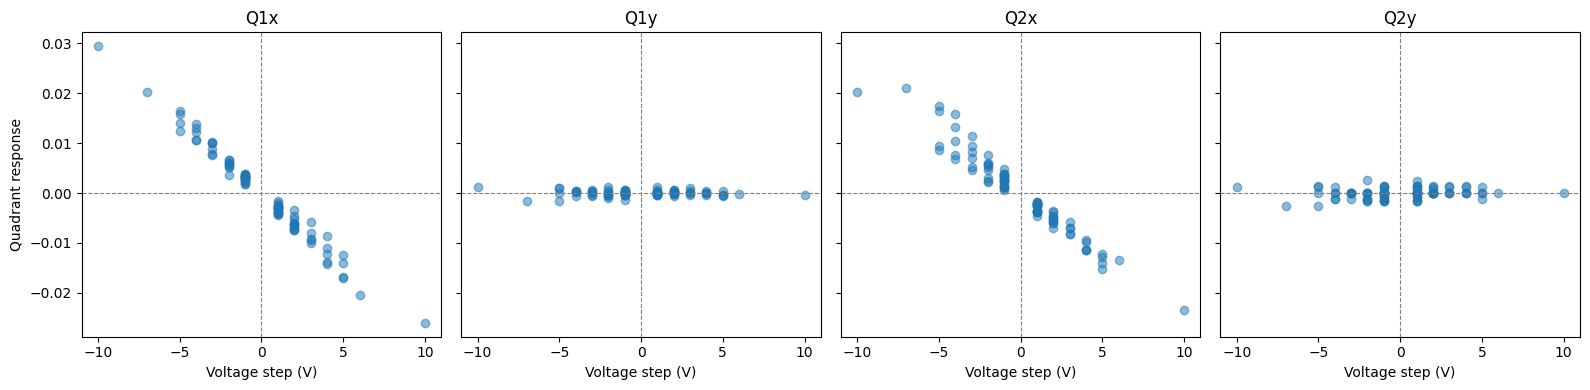

Mirror 2x
Jacobian: [[1.86346012e-03 1.06875891e-05 2.25576331e-03 5.25838252e-06]]


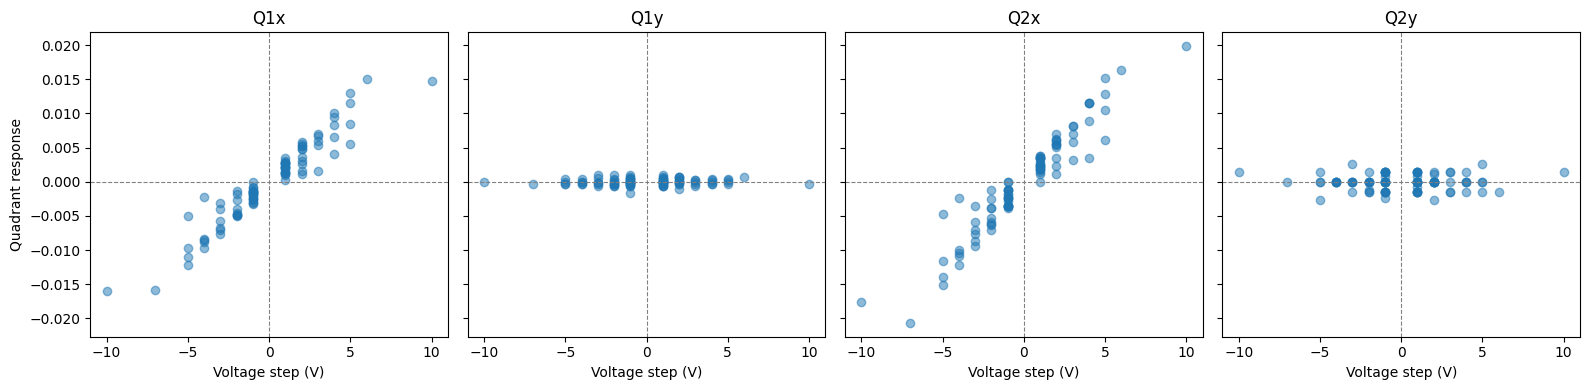

Mirror 3x
Jacobian: [[ 1.89785589e-03 -8.09326852e-06  2.51086036e-03 -6.36580069e-05]]


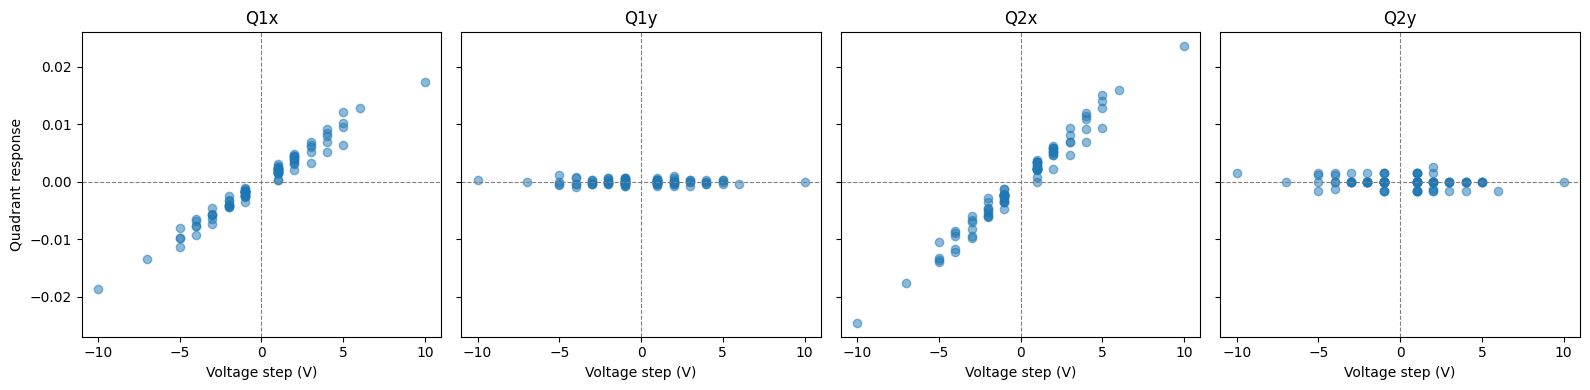

In [ ]:
# Plot After Conversion on Mar 10th: Ma

print("Mirror 1x")
plot_piezo(m_1)

print("Mirror 2x")
plot_piezo(m_2)

print("Mirror 3x")
plot_piezo(m_3)

Mirror 1x
Jacobian: [[-3.11677770e-03  2.43724208e-05 -3.85008417e-03  1.78208545e-05]]


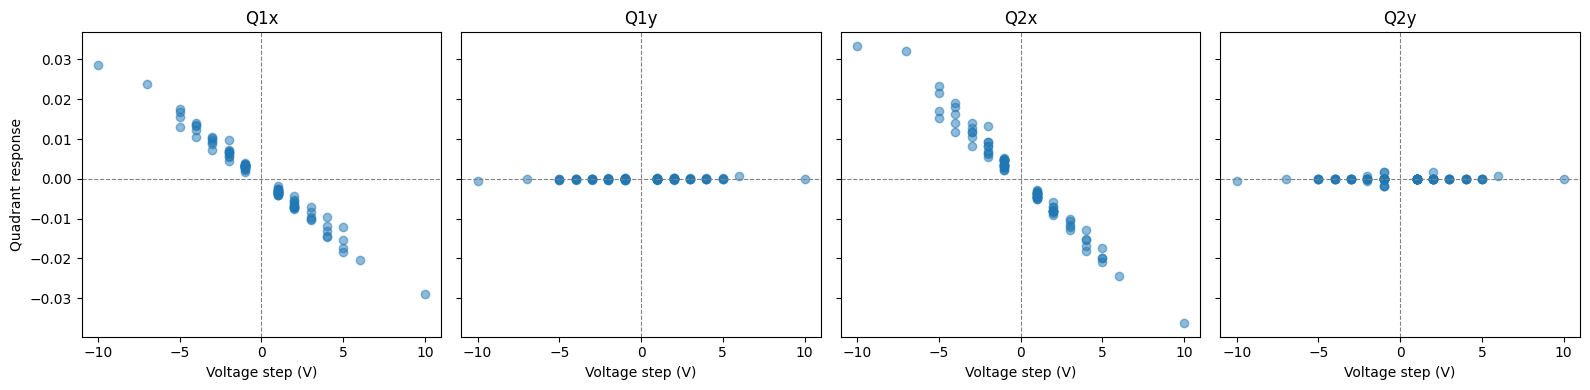

Mirror 2x
Jacobian: [[ 1.93127369e-03 -1.23628221e-05  2.46056442e-03 -4.23516474e-21]]


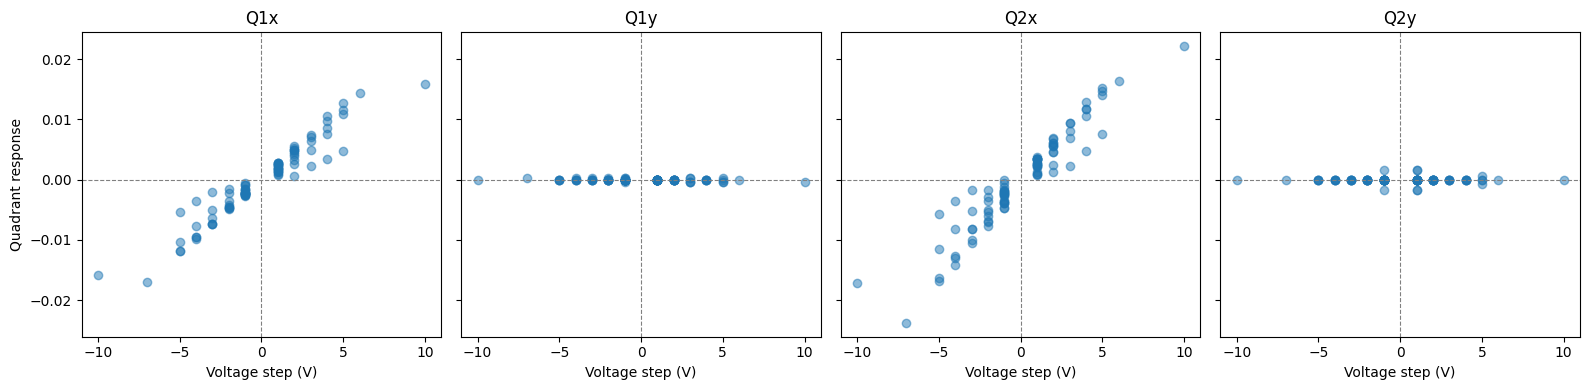

Mirror 3x
Jacobian: [[2.00462892e-03 1.37757161e-05 2.63578288e-03 1.12118137e-05]]


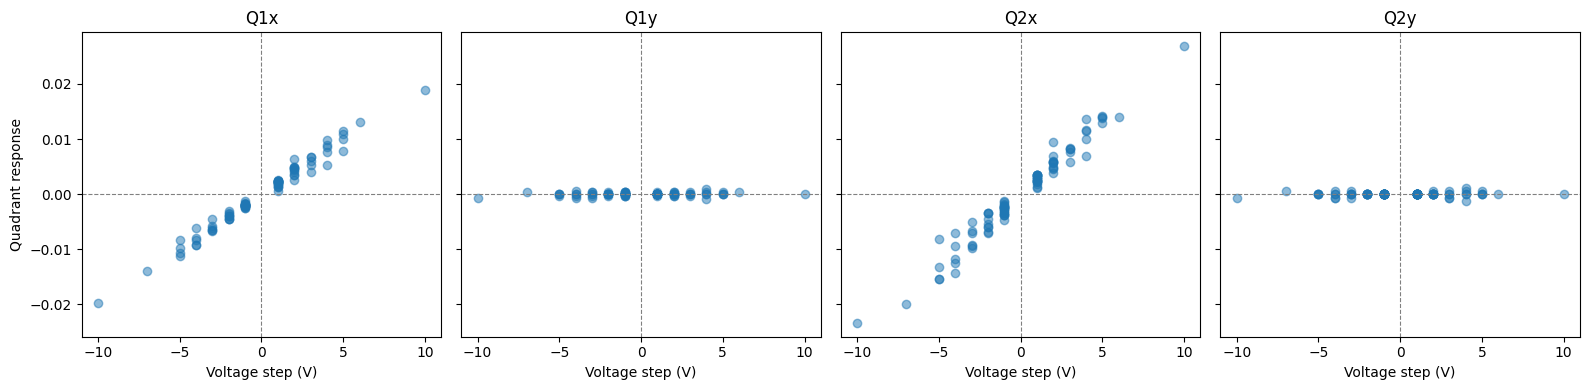

In [16]:
# Plot After Conversion

print("Mirror 1x")
plot_piezo(m_1)

print("Mirror 2x")
plot_piezo(m_2)

print("Mirror 3x")
plot_piezo(m_3)

Mirror 1x
Jacobian: [[-2.96419193e-03 -2.51320279e-05 -3.26787241e-03 -8.68095041e-06]]


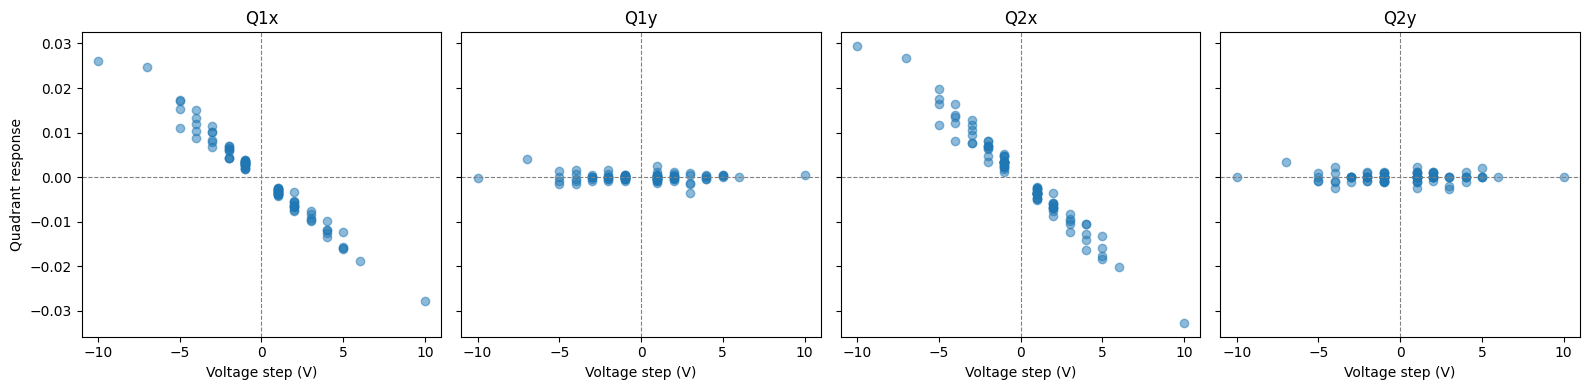

Mirror 2x
Jacobian: [[ 1.96532027e-03 -1.20438613e-05  2.16438412e-03 -1.99713725e-05]]


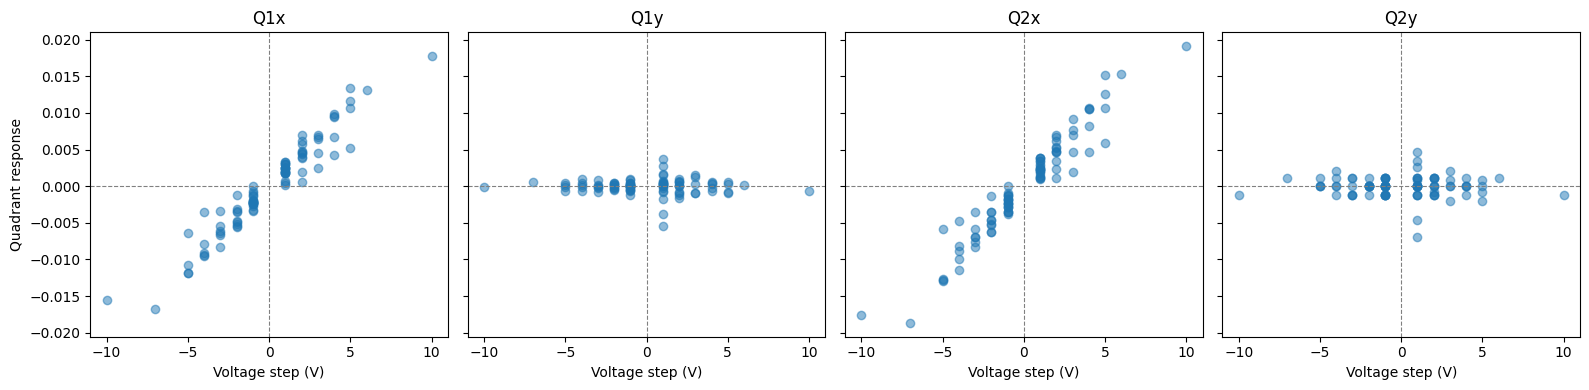

Mirror 3x
Jacobian: [[2.00740031e-03 2.11556851e-05 2.35656455e-03 1.75585566e-05]]


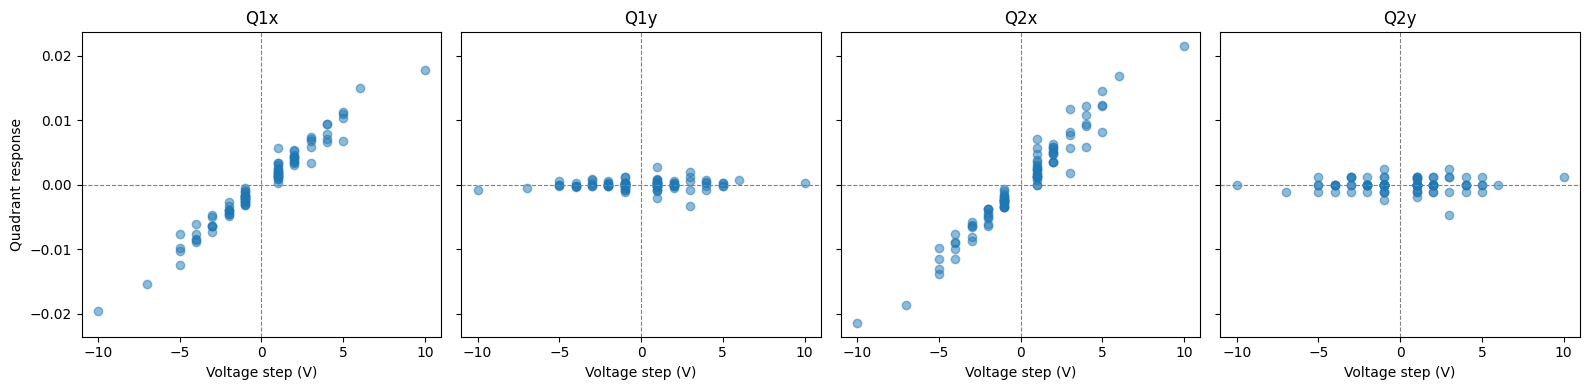

In [16]:
# Plot After Conversion

print("Mirror 1x")
plot_piezo(m1)

print("Mirror 2x")
plot_piezo(m2)

print("Mirror 3x")
plot_piezo(m3)

Mirror 1x
Jacobian: [[-2.95862675e-03 -2.37112896e-05 -8.53175237e-04 -1.74854071e-06]]


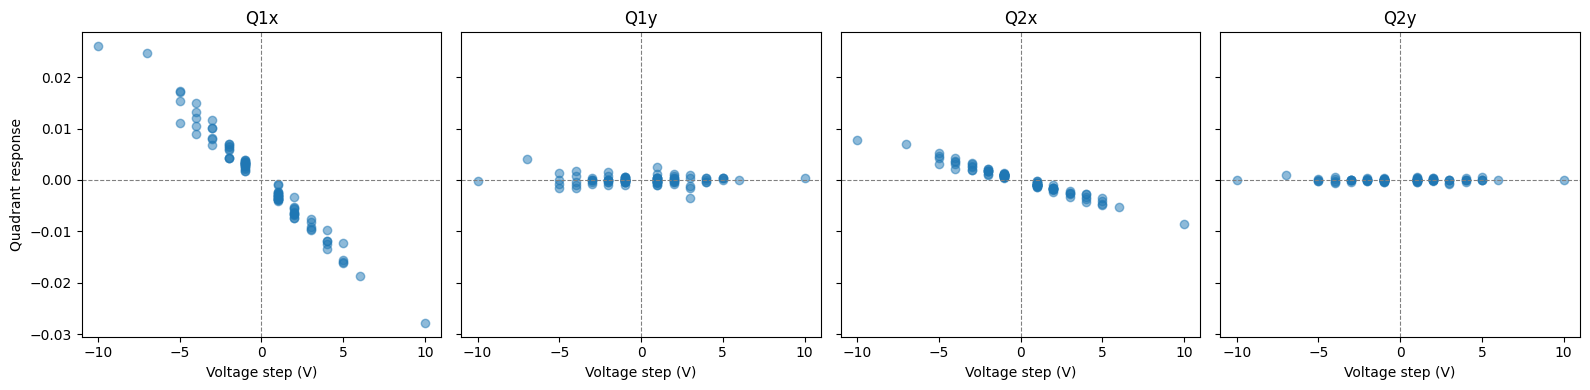

Mirror 2x
Jacobian: [[ 1.96453772e-03 -8.29194475e-06  5.65451288e-04 -3.91866055e-06]]


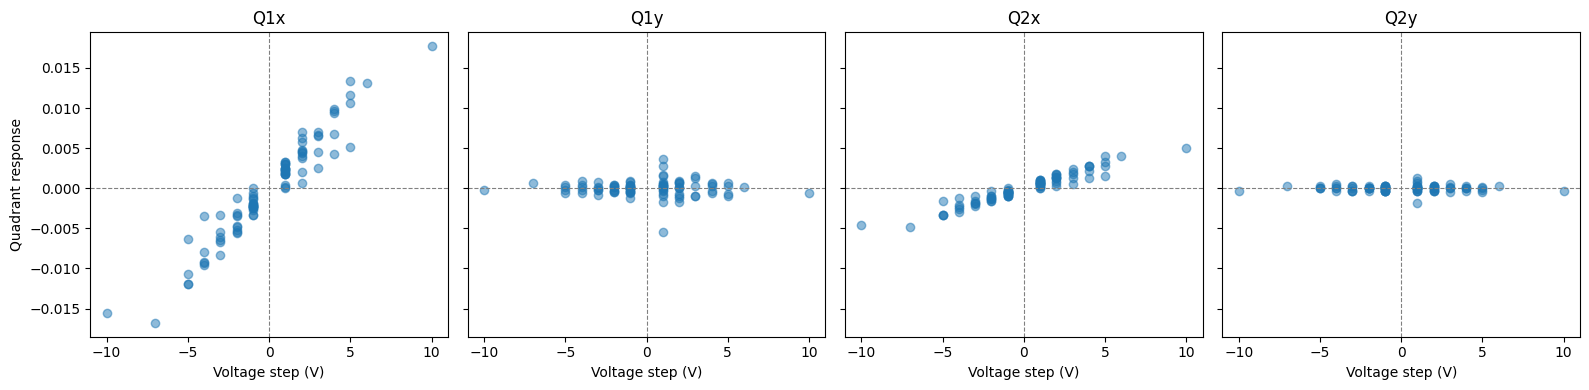

Mirror 3x
Jacobian: [[2.00460188e-03 2.17938774e-05 6.15505091e-04 5.04142584e-06]]


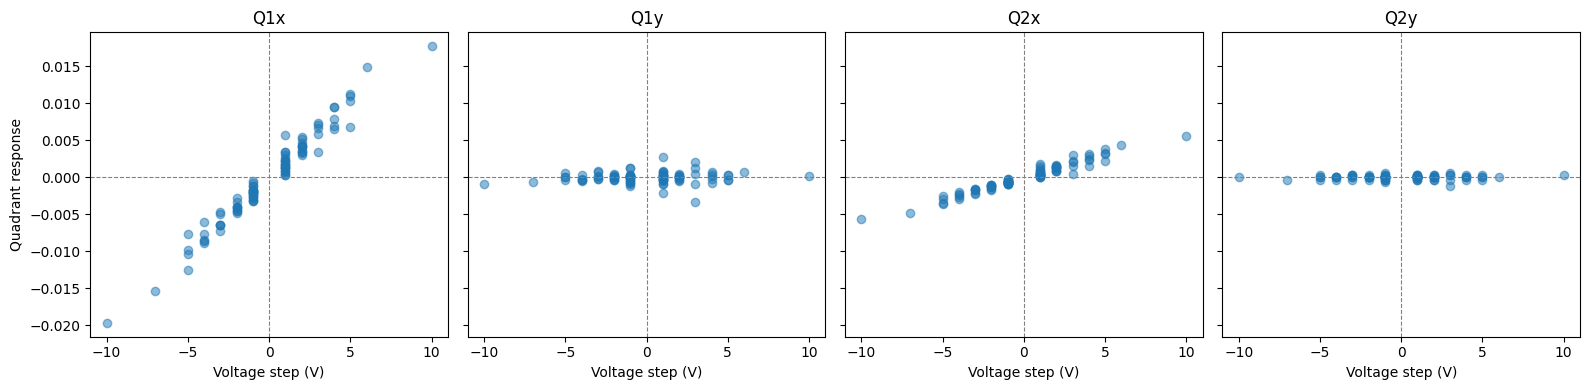

In [12]:
# Test All in 1 Run: Signal Strength Plot Comparison

print("Mirror 1x")
plot_piezo(m1)

print("Mirror 2x")
plot_piezo(m2)

print("Mirror 3x")
plot_piezo(m3)

In [ ]:
Jacobian1xa = [[-2.94133671e-03,  2.26217392e-05, -9.15949764e-04,  2.24108294e-05]]
Jacobian2xa = [[1.36409951e-03, 3.59759613e-05, 4.36964844e-04, 7.52751409e-06]]
Jacobian3xa = [[-1.10790603e-04,  1.00011976e-03, -1.35653950e-05,  4.16360231e-04]]
Jacobian1xb = [[-2.98880628e-03,  1.59173454e-05, -8.37707406e-04,  1.37602802e-05]]
Jacobian2xb = [[ 1.95629781e-03, -7.85321784e-06,  5.75296475e-04, -1.33744542e-06]]
Jacobian3xb = [[ 1.98116916e-03,  1.53291930e-06,  6.20406223e-04, -3.06583860e-06]]

In [41]:
M1 = []
M2 = []
M3 = []

In [ ]:
M1 = piezo_sweep(M1, [M1x], targets, step_size, False)
M2 = piezo_sweep(M2, [M2x], targets, step_size, False)
M3 = piezo_sweep(M3, [M3x], targets, step_size, False)

Mirror 1x
Jacobian: [[-2.94133671e-03  2.26217392e-05 -9.15949764e-04  2.24108294e-05]]


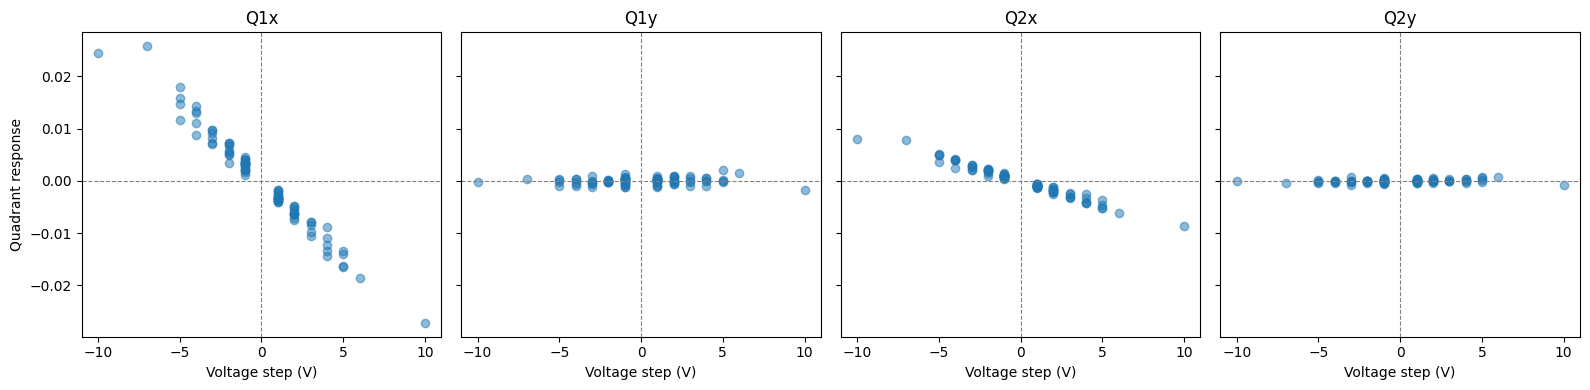

Mirror 2x
Jacobian: [[ 1.92471508e-03 -2.64849092e-05  6.26921995e-04 -1.49862836e-05]]


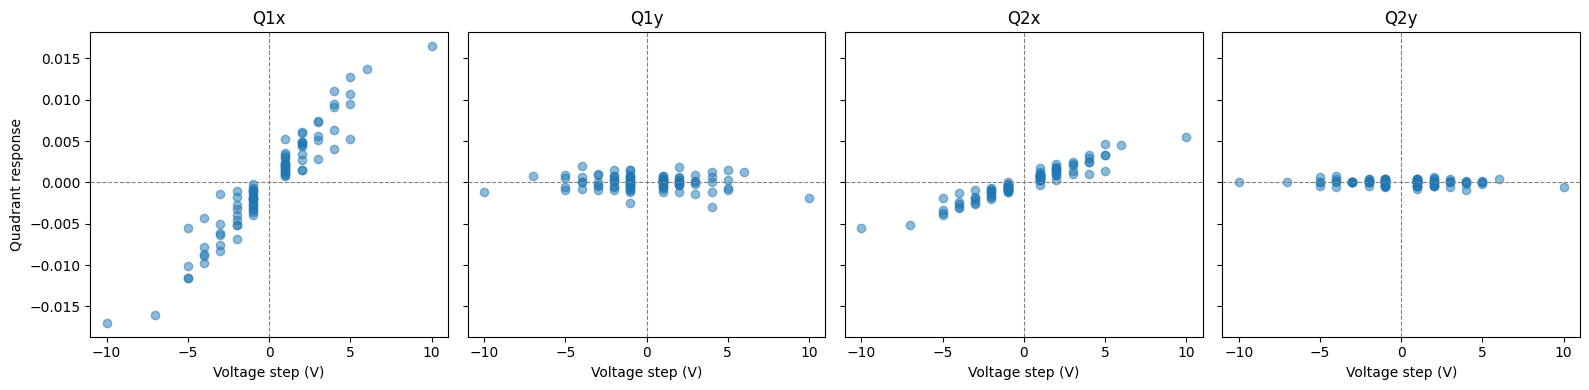

Mirror 3x
Jacobian: [[ 1.87262323e-03  7.37318712e-07  6.62235831e-04 -2.51028869e-06]]


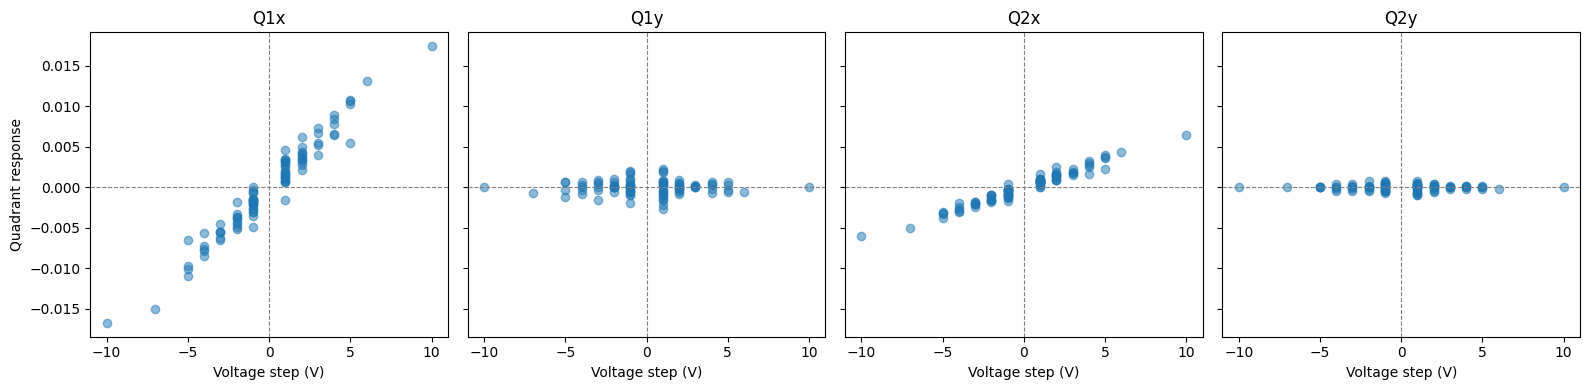

In [43]:
# Test All in 1 Run

print("Mirror 1x")
plot_piezo(M1)

print("Mirror 2x")
plot_piezo(M2)

print("Mirror 3x")
plot_piezo(M3)

In [45]:
M1

[{'v0': array([0.        , 0.04119999, 0.        , 0.        , 0.02746666,
         0.        ]),
  'v1': array([1.        , 0.04119999, 0.        , 0.        , 0.02746666,
         0.        ]),
  'before': array([-0.03784295, -0.00183111, -0.00549333, -0.00244148]),
  'after': array([-0.04      , -0.00183111, -0.006     , -0.00244148])},
 {'v0': array([1.        , 0.04119999, 0.        , 0.        , 0.02746666,
         0.        ]),
  'v1': array([2.        , 0.04119999, 0.        , 0.        , 0.02746666,
         0.        ]),
  'before': array([-0.04      , -0.00183111, -0.006     , -0.00244148]),
  'after': array([-0.04181036, -0.00152593, -0.00671407, -0.00244148])},
 {'v0': array([2.        , 0.04119999, 0.        , 0.        , 0.02746666,
         0.        ]),
  'v1': array([3.        , 0.04119999, 0.        , 0.        , 0.02746666,
         0.        ]),
  'before': array([-0.04181036, -0.00152593, -0.00671407, -0.00244148]),
  'after': array([-0.04364147, -0.00061037, -0.

In [46]:
np.save("M1.npy", M1, allow_pickle=True)

In [47]:
np.save("M2.npy", M2, allow_pickle=True)

In [48]:
np.save("M3.npy", M3, allow_pickle=True)

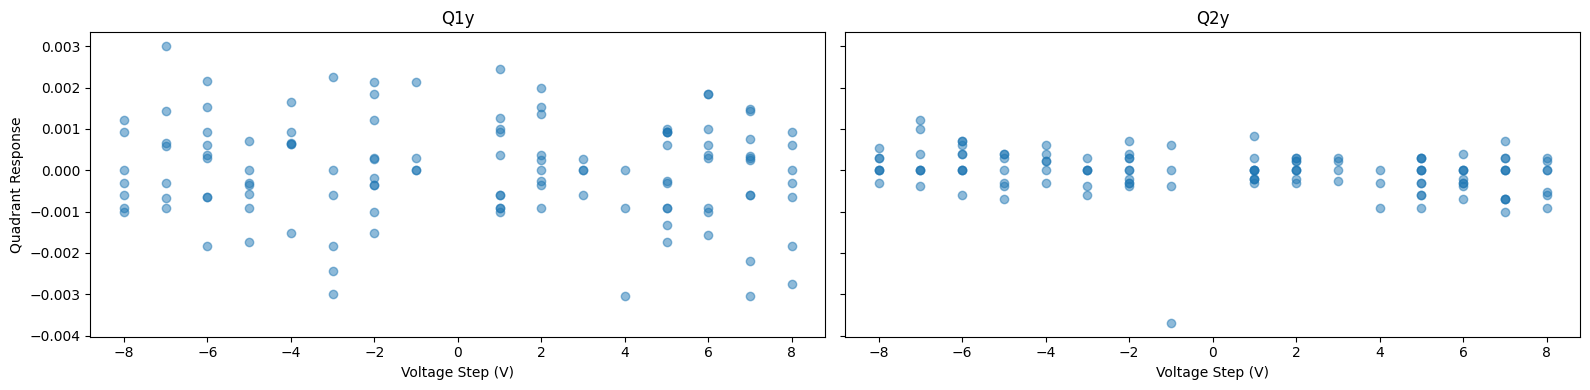

In [ ]:
V_r = np.array([m["v1"] - m["v0"] for m in m])  # shape (n_steps, n_axes)
Q_r = np.array([m["after"] - m["before"] for m in m])  # shape (n_steps, 4)
Vx = np.array([v[v != 0][0] for v in V_r])  # shape: (n_steps,)

# Create 1x4 subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

axs[0].scatter(Vx, Q_r[:, 1], alpha=0.5)
axs[0].set_title("Q1y")
axs[0].set_xlabel("Voltage Step (V)")
axs[0].set_ylabel("Quadrant Response")
axs[1].scatter(Vx, Q_r[:, 3], alpha=0.5)
axs[1].set_title("Q2y")
axs[1].set_xlabel("Voltage Step (V)")

plt.tight_layout()
plt.show()


In [10]:
# Initialize Storage for Each Mirror Jacobian
# For purpose of calculating multiple Jacobians to find average
Mirror_data = {
    "Mirror1x": [],
    "Mirror1y": [],
    "Mirror2x": [],
    "Mirror2y": [],
    "Mirror3x": [],
    "Mirror3y": [],
}

## Coarse Jacobian

In [ ]:
# Initialize Angular Stages
stage_ser = ops.stage_serials[0]
# Check Voltages of All Stages
print(ops.stages.get_all_positions())

channels = ['chan1', 'chan2', 'chan3', 'chan4']
step_size = 2   # your chosen step size

def compute_jacobian(channels, step_size, settle_time=0.5):

    pQ = []  # positions after positive moves
    nQ = []  # positions after negative moves

    for i, chan in enumerate(channels):
        # --- Positive move ---
        pos_before = ops.quads.get_xy_position(sig_strength=0.02)   # Initialize Pos
        pQ.append(pos_before)  
        loc_pos = ops.stages.get_all_positions() 
        pos_target = loc_pos[i] + step_size
        ops.stages.move_absolute(stage_ser, chan, pos_target)   # Move XY
        time.sleep(settle_time)
        pos_after = ops.quads.get_xy_position(sig_strength=0.02)  # Record Change
        pQ.append(pos_after)

        # --- Negative move ---
        neg_before = ops.quads.get_xy_position(sig_strength=0.02)   # Initialize Neg
        nQ.append(neg_before)
        loc_neg = ops.stages.get_all_positions()    # Initialize Loc
        neg_target = loc_neg[i] - step_size
        ops.stages.move_absolute(stage_ser, chan, neg_target)   # Move XY
        time.sleep(settle_time)
        neg_after = ops.quads.get_xy_position(sig_strength=0.02)  # Record Change
        nQ.append(neg_after)
    # For Chan 1, Chan 2, Chan 3, Chan 4

    pM = []
    nM = []

    for i in range(len(channels)):
        a = pQ[2*i+1] # after
        b = pQ[2*i+0] # before
        pM.append([pa - pb for pa, pb in zip(a,b)])

        c = nQ[2*i+1] # after
        d = nQ[2*i+0] # before
        nM.append([na - nb for na, nb in zip(c,d)])

    pM = np.array(pM)*2/step_size # Doubling 'cause of mirror law & dividing by initial step jump: pM is the linear movement of laser per singular input
    nM = np.array(nM)*2/-step_size

    print("Positive Jacobian")
    print(pM)
    print("Negative Jacobian")
    print(nM)

    pMX = [pM[0,:], pM[2,:]]
    pMY = [pM[1,:], pM[3,:]]
    nMX = [nM[0,:], nM[2,:]]
    nMY = [nM[1,:], nM[3,:]]

    print("Positive X Jacobian:")
    for row in pMX:
        print("  ".join(f"{val:8.4f}" for val in row))
    print("Positive Y Jacobian:")
    for row in pMY:
        print("  ".join(f"{val:8.4f}" for val in row))
    print("Negative X Jacobian:")
    for row in nMX:
        print("  ".join(f"{val:8.4f}" for val in row))
    print("Negative Y Jacobian:")
    for row in nMY:
        print("  ".join(f"{val:8.4f}" for val in row))
    
    return pM, nM

def distribution_grid(raw_list, names):
    """
    Plot X and Y distributions for multiple mirrors in a 2x2 grid.
    
    raw_list: list of 4 datasets (each dataset = list of rows)
    names: list of 4 names corresponding to the mirrors
    """
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))  # 4 rows, 2 columns

    for i, (raw, name) in enumerate(zip(raw_list, names)):
        data = np.array([np.array(row) for row in raw], dtype=float)
        dB1x, dB1y = data[:,0], data[:,1]
        dB2x, dB2y = data[:,2], data[:,3]

        # X component
        axes[i, 0].hist(dB1x, bins=40, alpha=0.5, label="Quadcell 1")
        axes[i, 0].hist(dB2x, bins=40, alpha=0.5, label="Quadcell 2")
        axes[i, 0].set_title(f"Mirror: {name} — X Distribution")
        axes[i, 0].set_xlabel("dB_x")
        axes[i, 0].set_ylabel("Frequency")
        axes[i, 0].legend()
        axes[i, 0].grid(True)

        # Y component
        axes[i, 1].hist(dB1y, bins=40, alpha=0.5, label="Quadcell 1")
        axes[i, 1].hist(dB2y, bins=40, alpha=0.5, label="Quadcell 2")
        axes[i, 1].set_title(f"Mirror: {name} — Y Distribution")
        axes[i, 1].set_xlabel("dB_y")
        axes[i, 1].set_ylabel("Frequency")
        axes[i, 1].legend()
        axes[i, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Finds mean jacobian from data
def compute_jacobian_from_data(mirror_data, step_size):
    """
    mirror_data : list of 4 lists
        mirror_data[0] = +Y responses (50×4)
        mirror_data[1] = -Y responses (50×4)
        mirror_data[2] = +X responses (50×4)
        mirror_data[3] = -X responses (50×4)
    step_size : scalar piezo step used in piezo_Jacobian()
    """

    # Convert lists → arrays
    posY = np.array(mirror_data[0])  # (50 × 4)
    negY = np.array(mirror_data[1])
    posX = np.array(mirror_data[2])
    negX = np.array(mirror_data[3])

    # Mean responses
    mean_dQ_posY = np.mean(posY, axis=0)
    mean_dQ_negY = np.mean(negY, axis=0)
    mean_dQ_posX = np.mean(posX, axis=0)
    mean_dQ_negX = np.mean(negX, axis=0)

    # Jacobian estimate (4×2)
    J = np.zeros((4, 2))

    # central difference for Y-column
    J[:, 0] = (mean_dQ_posY - mean_dQ_negY) / (2 * step_size)

    # central difference for X-column
    J[:, 1] = (mean_dQ_posX - mean_dQ_negX) / (2 * step_size)

    # Uncertainty (standard deviation of estimates)
    dJ_samples_Y = (posY - negY) / (2 * step_size)
    dJ_samples_X = (posX - negX) / (2 * step_size)

    J_std = np.zeros((4,2))
    J_std[:,0] = np.std(dJ_samples_Y, axis=0)
    J_std[:,1] = np.std(dJ_samples_X, axis=0)

    return J, J_std


In [ ]:
# Mandatory Shutdown of System - Must be run if piezo's moved
ops.piezos.shutdown()
ops.quads.shutdown()
ops.stages.shutdown()